# Self-Repair Parsing Pilot Study Report

**Model:** `Shrikes/sbn-gemma2-9b-lora-pmb` — LoRA-finetuned Gemma-2-9B, trained on PMB 5.1.0 gold SBN only. No self-repair examples were in the training data.  
**Data:** `Shrikes/self_repair_parsing_pilot_data` — 836 sentences, each parsed under 7 conditions and scored against the same gold graph.  
**Scoring:** smatch++ (`flipz357/smatchpp`).

This report answers four questions:

1. **Q1 — Performance.** How does the parser handle self-repair input when it has never been trained on repair structure?
2. **Q2 — Position effect.** Does *where* the reparandum sits (head / mid / tail), or *whether* an interregnum ("I mean") is present, systematically affect parsing?
3. **Q3 — Mechanism.** Why does the smatch++ score stay reasonably high, given the model has no explicit repair-handling knowledge?
4. **Q4 — Ablation.** Independent of the SBN-generation task, does the base model itself recognise and localize self-repair, zero-shot?

Q1 and Q2 are quantitative and computed directly in this notebook. Q3 draws on a small hand-coded qualitative sample and is reported at the more tentative confidence level that a sample of that size supports. Q4 reports a separate ablation (own data/scoring pipeline in `colloquium_prep/ablation_repair_sensitivity/`) that isolates the SBN task as a variable.

This notebook is composed by Claude. The content is checked and confirmed by Hongxu Zhou.

## Setup

| group | conditions |
|---|---|
| baseline | `gold` |
| repair (plain) | `repair_head`, `repair_mid`, `repair_tail` |
| repair (+ interregnum "I mean") | `repair_head_interrug`, `repair_mid_interrug`, `repair_tail_interrug` |

**Status codes:** `success` (scored normally) · `ill_formed` (predicted graph rejected by strict-mode index checks) · `parse_error` (predicted graph not usable by the scorer, e.g. contains a cycle) · `gold_error` (the gold graph itself failed — not the model's fault) · `smatch_error` (scorer crashed).

**Two F1 numbers, used for different purposes:**
- **F1 (success-only):** average F1 over rows that succeeded. Answers "when it produces a scoreable graph, how good is it?"
- **F1 (penalised):** average F1 over *all* rows, counting every failure as F1 = 0. This is the headline number: it does not let a parser hide behind "just don't produce failing output."

In [1]:
import itertools
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import chi2, friedmanchisquare, wilcoxon
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

DATA_PATH = Path("../preds_long_scored.parquet")
QUAL_PATH = Path("qualitative_sample.tsv")
FIG_DIR = Path("figures_pilot_report"); FIG_DIR.mkdir(exist_ok=True)

CONDITION_ORDER = [
    "gold",
    "repair_head", "repair_mid", "repair_tail",
    "repair_head_interrug", "repair_mid_interrug", "repair_tail_interrug",
]
POSITION_ORDER = ["head", "mid", "tail"]
STATUS_ORDER = ["success", "ill_formed", "parse_error", "gold_error", "smatch_error"]
VANILLA = ["repair_head", "repair_mid", "repair_tail"]
INTERREG = ["repair_head_interrug", "repair_mid_interrug", "repair_tail_interrug"]

df = pd.read_parquet(DATA_PATH)
df["f1"] = pd.to_numeric(df["f1"], errors="coerce")
df["condition"] = pd.Categorical(df["condition"], categories=CONDITION_ORDER, ordered=True)

def position(c):
    for p in POSITION_ORDER:
        if f"_{p}" in c:
            return p
    return "—"

df["position"] = df["condition"].astype(str).map(position)
df["has_interregnum"] = df["condition"].astype(str).str.contains("interrug")
df["f1_pen"] = df["f1"].where(df["status"] == "success", 0.0)

print(f"{len(df)} rows | {df['id'].nunique()} sentences | {df['condition'].nunique()} conditions")

5852 rows | 836 sentences | 7 conditions


## Q1 — How does the parser handle self-repair?

In [2]:
def summarize(g):
    n = len(g)
    ok = (g["status"] == "success").sum()
    succ_f1 = g.loc[g["status"] == "success", "f1"]
    return pd.Series({
        "N": n,
        "success_%": round(100 * ok / n, 1),
        "F1_success_only": round(succ_f1.mean(), 3) if len(succ_f1) else np.nan,
        "F1_penalized": round(g["f1_pen"].mean(), 3),
    })

summary = df.groupby("condition", observed=True).apply(summarize).reindex(CONDITION_ORDER)
summary

,N,success_%,F1_success_only,F1_penalized
condition,,,,
gold,836.0,97.1,0.975,0.947
repair_head,836.0,95.5,0.842,0.804
repair_mid,836.0,92.0,0.827,0.760
repair_tail,836.0,95.2,0.825,0.785
repair_head_interrug,836.0,86.6,0.805,0.697
repair_mid_interrug,836.0,71.5,0.779,0.557
repair_tail_interrug,836.0,70.5,0.803,0.566


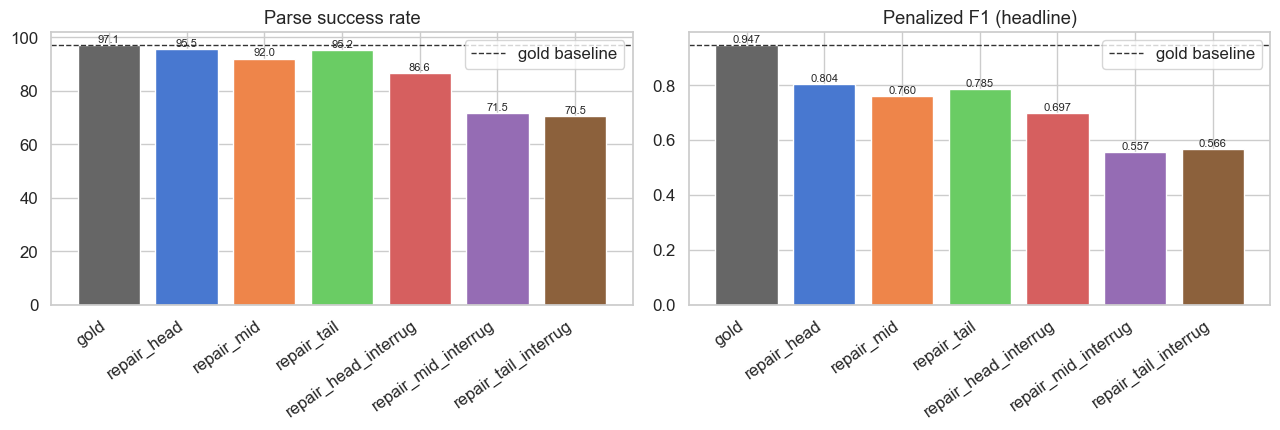

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
colors = ["#666666"] + sns.color_palette("muted", 6)

for ax, col, title in zip(axes, ["success_%", "F1_penalized"], ["Parse success rate", "Penalized F1 (headline)"]):
    ax.bar(summary.index.astype(str), summary[col], color=colors)
    ax.axhline(summary.loc["gold", col], ls="--", c="#333333", lw=1, label="gold baseline")
    ax.set_title(title)
    ax.set_xticks(range(len(summary.index)))
    ax.set_xticklabels(summary.index.astype(str), rotation=35, ha="right")
    ax.legend()
    for i, v in enumerate(summary[col]):
        offset = 1 if col == "success_%" else 0.01
        fmt = f"{v:.1f}" if col == "success_%" else f"{v:.3f}"
        ax.text(i, v + offset, fmt, ha="center", fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "q1_summary.png", dpi=150)
plt.show()

**Reading the numbers.** Gold itself is not perfect (97.1% success, F1 0.947) — this is the parser's own error floor, and everything below should be read relative to it, not to 1.0. Plain repair (`repair_*`) costs roughly 2–6 success points and brings penalized F1 down to about 0.76–0.80. Adding an interregnum ("I mean") is a much bigger hit: success falls to 70–87%, penalized F1 to 0.56–0.70.

Two things stand out here and set up the rest of this report:

1. The drop is not uniform across head/mid/tail — **Q2** tests whether that is a systematic position effect or noise.
2. Even in the worst condition, the parser still recovers roughly half its F1, despite never having seen repair structure in training — **Q3** asks what mechanism produces that residual score.

## Q2 — Does position, or the presence of an interregnum, systematically affect parsing?

**Disclaimer:** Claude assisted in proposing statistical approaches and generating corresponding code. Final methodological decisions, code verification, analysis execution, and interpretation of results were conducted solely by me.

Vanilla repair (`repair_*`) and interregnum repair (`repair_*_interrug`) are analysed as **two separate designs**, not as two steps of one escalating difficulty ladder. This is a deliberate analytical decision because treating them as a ladder assumes the hardest position stays the same once an interregnum is added, which the results below do not support.

Within each group, the same sentence appears in all three positions, so this is a **repeated-measures / paired design**: paired tests, not independent-sample tests. Two outcomes are tested separately because they capture different things:

- **Success / fail** — does the parser produce a scoreable graph at all?
- **F1 among successes** — given that it did, how good is that graph?

In [4]:
# 3 sentences have a gold-side error in every condition — a data defect, not model behaviour.
gold_error_ids = df.loc[df["status"] == "gold_error", "id"].unique()
df_q2 = df[~df["id"].isin(gold_error_ids)].copy()
print(f"Excluded {len(gold_error_ids)} sentences with a gold-side error: {list(gold_error_ids)}")
print(f"N = {df_q2['id'].nunique()} sentences remain.")

Excluded 3 sentences with a gold-side error: ['p04/d2024', 'p05/d0919', 'p69/d1719']
N = 833 sentences remain.


### Test statistics

- **Cochran's Q** — omnibus test for success/fail across the 3 paired conditions in a group (McNemar generalised to k > 2).
- **McNemar's test** — pairwise follow-up for success/fail; uses only the sentences where the two conditions disagree.
- **Friedman test** — omnibus test for F1 across the 3 paired conditions (non-parametric repeated-measures ANOVA analogue; F1 is bounded and non-normal).
- **Wilcoxon signed-rank test** — pairwise follow-up for F1.
- **Holm correction** — applied to the 3 pairwise tests within each group, since 3 comparisons are run from the same data.

All functions are implemented directly from their standard formulas below, so the computation is visible rather than hidden inside a library call.

In [5]:
def cochrans_q(mat):
    """mat: N x k binary matrix, 1 = success. Tests whether success rate differs across k paired conditions."""
    N, k = mat.shape
    col_sums, row_sums = mat.sum(axis=0), mat.sum(axis=1)
    Cbar = col_sums.mean()
    num = k * (k - 1) * np.sum((col_sums - Cbar) ** 2)
    den = k * row_sums.sum() - np.sum(row_sums ** 2)
    Q = num / den
    dfree = k - 1
    return Q, dfree, chi2.sf(Q, dfree)


def mcnemar(a, b):
    """Paired binary vectors. Compares only the discordant pairs (where a and b disagree), chi2 with continuity correction."""
    n01, n10 = np.sum((a == 0) & (b == 1)), np.sum((a == 1) & (b == 0))
    n = n01 + n10
    if n == 0:
        return np.nan, 1.0
    stat = (abs(n01 - n10) - 1) ** 2 / n
    return stat, chi2.sf(stat, 1)


def holm_correct(pvals):
    """Step-down Holm correction for a small family of pairwise tests."""
    order = np.argsort(pvals)
    adj, running_max = np.empty(len(pvals)), 0.0
    for rank, idx in enumerate(order):
        running_max = max(running_max, (len(pvals) - rank) * pvals[idx])
        adj[idx] = min(running_max, 1.0)
    return adj

In [6]:
def run_group(conditions, label):
    sub = df_q2[df_q2["condition"].isin(conditions)].copy()
    sub["success"] = (sub["status"] == "success").astype(int)
    pairs = list(itertools.combinations(conditions, 2))

    # success / fail
    wide_succ = sub.pivot(index="id", columns="condition", values="success").dropna()[conditions]
    Q, dfree, pQ = cochrans_q(wide_succ.values)
    stats = np.array([mcnemar(wide_succ[a].values, wide_succ[b].values)[0] for a, b in pairs])
    raw_p = np.array([mcnemar(wide_succ[a].values, wide_succ[b].values)[1] for a, b in pairs])
    holm_p = holm_correct(raw_p)
    succ_pairwise = pd.DataFrame({
        "pair": [f"{a} vs {b}" for a, b in pairs], "chi2": stats.round(3),
        "p_raw": raw_p, "p_holm": holm_p, "significant": holm_p < 0.05,
    })

    print(f"=== {label}: success / fail (N={len(wide_succ)}) ===")
    print(wide_succ.mean().round(4).to_string())
    print(f"Cochran's Q = {Q:.2f}, df={dfree}, p = {pQ:.3g}\n")
    display(succ_pairwise)

    # F1 among successes (complete-case triplets)
    wide_f1 = sub.pivot(index="id", columns="condition", values="f1")[conditions].dropna()
    stat_fr, p_fr = friedmanchisquare(*[wide_f1[c] for c in conditions])
    stats_w = np.array([wilcoxon(wide_f1[a], wide_f1[b])[0] for a, b in pairs])
    raw_p2 = np.array([wilcoxon(wide_f1[a], wide_f1[b])[1] for a, b in pairs])
    holm_p2 = holm_correct(raw_p2)
    f1_pairwise = pd.DataFrame({
        "pair": [f"{a} vs {b}" for a, b in pairs], "W": stats_w.round(1),
        "p_raw": raw_p2, "p_holm": holm_p2, "significant": holm_p2 < 0.05,
    })

    print(f"=== {label}: F1 among successes (complete-case N={len(wide_f1)}) ===")
    print(wide_f1.mean().round(4).to_string())
    print(f"Friedman chi2 = {stat_fr:.2f}, p = {p_fr:.3g}\n")
    display(f1_pairwise)
    print()

    return {
        "conditions": conditions, "pairs": pairs,
        "succ_rate": wide_succ.mean(), "succ_pairwise": succ_pairwise,
        "f1_mean": wide_f1.mean(), "f1_pairwise": f1_pairwise,
    }

vanilla_res = run_group(VANILLA, "Vanilla")
interreg_res = run_group(INTERREG, "Interregnum")

=== Vanilla: success / fail (N=833) ===
condition
repair_head    0.9580
repair_mid     0.9232
repair_tail    0.9556
Cochran's Q = 14.85, df=2, p = 0.000596



,pair,chi2,p_raw,p_holm,significant
0,repair_head vs repair_mid,10.453,0.001224,0.003673,True
1,repair_head vs repair_tail,0.017,0.897279,0.897279,False
2,repair_mid vs repair_tail,8.779,0.003047,0.006094,True


=== Vanilla: F1 among successes (complete-case N=722) ===
condition
repair_head    0.8427
repair_mid     0.8267
repair_tail    0.8248
Friedman chi2 = 26.14, p = 2.11e-06



,pair,W,p_raw,p_holm,significant
0,repair_head vs repair_mid,91947.5,9.739339e-06,0.000019,True
1,repair_head vs repair_tail,91129.0,8.665222e-07,0.000003,True
2,repair_mid vs repair_tail,99562.5,4.389073e-01,0.438907,False



=== Interregnum: success / fail (N=833) ===
condition
repair_head_interrug    0.8691
repair_mid_interrug     0.7179
repair_tail_interrug    0.7071
Cochran's Q = 84.61, df=2, p = 4.24e-19



,pair,chi2,p_raw,p_holm,significant
0,repair_head_interrug vs repair_mid_interrug,63.004,2.062838e-15,4.125677e-15,True
1,repair_head_interrug vs repair_tail_interrug,64.358,1.037240e-15,3.111721e-15,True
2,repair_mid_interrug vs repair_tail_interrug,0.228,6.331912e-01,6.331912e-01,False


=== Interregnum: F1 among successes (complete-case N=408) ===
condition
repair_head_interrug    0.8094
repair_mid_interrug     0.7804
repair_tail_interrug    0.8053
Friedman chi2 = 18.02, p = 0.000122



,pair,W,p_raw,p_holm,significant
0,repair_head_interrug vs repair_mid_interrug,29320.0,0.000042,0.000126,True
1,repair_head_interrug vs repair_tail_interrug,39204.5,0.762861,0.762861,False
2,repair_mid_interrug vs repair_tail_interrug,26305.5,0.000245,0.000490,True


### Which position is the odd one out?

The pairwise tables above always show the same shape: two conditions are statistically indistinguishable from each other, and the third differs significantly from both. The cell below extracts that pattern automatically for all four (group × outcome) results, rather than reading it off the tables by eye.

In [7]:
def classify_pattern(res, pairwise_key, rate_key, alpha=0.05):
    conditions = res["conditions"]
    pairwise = res[pairwise_key]
    rates = res[rate_key]
    sig = {frozenset(row["pair"].split(" vs ")): row["significant"] for _, row in pairwise.iterrows()}
    nonsig_pairs = [p for p, s in sig.items() if not s]
    if len(nonsig_pairs) == 1:
        tied = nonsig_pairs[0]
        outlier = [c for c in conditions if c not in tied][0]
        direction = "higher" if rates[outlier] > np.mean([rates[t] for t in tied]) else "lower"
        return outlier, direction, tied
    elif len(nonsig_pairs) == 3:
        return None, "no significant difference among any pair", set(conditions)
    else:
        return None, "all three positions pairwise distinct", set()

def pos(c):
    for p in POSITION_ORDER:
        if f"_{p}" in c:
            return p

rows = []
for group_label, res in [("vanilla", vanilla_res), ("interregnum", interreg_res)]:
    for outcome_label, pairwise_key, rate_key in [
        ("success/fail", "succ_pairwise", "succ_rate"),
        ("F1 among successes", "f1_pairwise", "f1_mean"),
    ]:
        outlier, direction, tied = classify_pattern(res, pairwise_key, rate_key)
        rows.append({
            "group": group_label, "outcome": outcome_label,
            "odd one out": pos(outlier) if outlier else "-",
            "direction": direction,
            "tied pair": ", ".join(sorted(pos(t) for t in tied)) if outlier else "-",
        })

outlier_map = pd.DataFrame(rows)
outlier_map

,group,outcome,odd one out,direction,tied pair
0,vanilla,success/fail,mid,lower,"head, tail"
1,vanilla,F1 among successes,head,higher,"mid, tail"
2,interregnum,success/fail,head,higher,"mid, tail"
3,interregnum,F1 among successes,mid,lower,"head, tail"


**Reading the map.** In every one of the four tests, one position separates from the other two, which are statistically tied. But *which* position is the odd one out flips depending on the outcome and the group:

- **Vanilla, success/fail:** mid is the odd one out (lower); head and tail are tied and higher.
- **Vanilla, F1:** head is the odd one out (higher); mid and tail are tied and lower.
- **Interregnum, success/fail:** head is the odd one out (higher); mid and tail are tied and lower.
- **Interregnum, F1:** mid is the odd one out (lower); head and tail are tied and higher.

Head and mid keep a stable identity across all four combinations: head is never the worst, mid is never the best. **Tail is the only position whose grouping changes**: it sides with head in vanilla-success and interregnum-F1, and with mid in vanilla-F1 and interregnum-success. This is a stronger and more specific claim than "position matters" or "the effect is non-monotonic". It says the two outcomes (getting a scoreable graph vs. the quality of that graph) are governed by different position splits, and the identity of the split depends on whether an interregnum is present.

One honest caveat: the F1 test uses complete-case triplets (sentences that succeeded in *all three* conditions of a group), which is 87% of sentences for vanilla but only 49% for interregnum. This under-represents exactly the harder sentences that fail at mid/tail, so the F1 finding should be read with that selection effect in mind.

## Q3 — Why does the score stay this high?

**Scope note.** To understand why the smatch++ score is relatively high even though the model does not have the knowledge of self-repair resolution, I sampled and analysed 107 samples. Group A is the core of this analysis. It contains 7 varieties (inlcuding the original gold version) of 7 PMB train gold samples. 

In [8]:
qual = pd.read_csv(QUAL_PATH, sep="\t")
qual["sample_group"].value_counts()

sample_group
A_longitudinal                   49
B_failure_survey                 37
C_manual_repairs_known_defect    21
Name: count, dtype: int64

### The core observation

The model has no systematic understanding of self-repair. It does not identify and discard the reparandum. Instead, it produces a formally-legal-looking SBN sequence by gluing and sewing the reparandum and the repair together — at the cost of meaning, not at the cost of surface well-formedness. Because the gold triples usually survive as a subset of this bloated output, precision drops but recall holds, and F1 stays in an acceptable range. This gluing behaviour, not repair competence, is what sustains the score.

### Vanilla repair: three gluing devices, one per position

| position | device | example (from the coded sample) |
|---|---|---|
| head | reparandum left as a weakly-connected / "free-loading" node | `p31/d3309`, *"Jerry, Tom threw a rock at Mary..."* — coder's note: *"the male jerry node looks like free loading in the SBN"* |
| mid | reparandum and repair treated as a coordinated pair (`entity.n.01 Sub -1 Sub +1`) | `p31/d3309`, *"Tom threw a book, a rock at Mary..."* — coder's note: *"entity sub -1 sub +1 is a standard coordination structure... relative index is wrong as well"* |
| tail | reparandum and repair serialised with `CONTINUATION` | `p07/d1400`, *"...in love with her, me?"* — coder's note: *"use CONTINUATION to forcibly glue the repair to the reparandum"* |

### Interregnum repair: two behaviors, neither reflecting the discourse function of "I mean"

- **Gluing:** "I mean" is parsed as a propositional speech act and wrapped around both sides of the repair, e.g. `p31/d3309` interregnum-head — coder's note: *"the 'I mean' is represented instead of being treated as a metalinguistic label, this causes a big and complex graph."* When the sentence is structurally complex, this extra material has previously been found (manual inspection in an earlier analysis pass, not recomputed here) to frequently push the graph into a directed cycle which is invalid for the DAG format smatch++ requires, which is why interregnum conditions have a much higher `parse_error` rate (see the table below).
- **Selective omission:** the model drops the repair and outputs a clean graph from the reparandum alone, e.g. `p07/d1400` interregnum-mid:

time.n.08 EQU now  
entity.n.01  
true.a.01 Time -2 Proposition >1 EQU -1  
CONTINUATION <0  
person.n.01  EQU speaker **the I is skipped**  
time.n.08 EQU now  
in_love.a.01 Experiencer -2 Time -1 Stimulus +1  
person.n.01 EQU hearer  
For the sentence "Is it true that I am, I mean, you are in love with me?"  

This does not tank the score, because the reparandum and repair usually share the same event frame and differ in only one substituted argument. As a result, the wrong filler lands in the right structural slot.

In [9]:
status_counts = (
    df.groupby("condition", observed=True)["status"]
    .value_counts().unstack(fill_value=0)
    .reindex(index=CONDITION_ORDER, columns=STATUS_ORDER, fill_value=0)
)
status_counts

status,success,ill_formed,parse_error,gold_error,smatch_error
condition,,,,,
gold,812,14,7,3,0
repair_head,798,23,12,3,0
repair_mid,769,36,28,3,0
repair_tail,796,15,22,3,0
repair_head_interrug,724,20,89,3,0
repair_mid_interrug,598,30,205,3,0
repair_tail_interrug,589,14,230,3,0


**Reading the table.** `parse_error` is rare in vanilla conditions (12–28 sentences) but jumps sharply in interregnum conditions (89–230 sentences), being consistent with the gluing-into-a-cycle mechanism above being the dominant new failure mode once "I mean" is introduced.

### Connecting back to Q2: where the mechanism explains the position pattern, and where it does not

- **Interregnum success/fail (head high, mid/tail low) — well supported.** `parse_error` counts are lowest for `repair_head_interrug` (89) and much higher for `repair_mid_interrug` (205) and `repair_tail_interrug` (230), matching the Q2 outlier map directly. The gluing-into-a-cycle failure mode is concentrated exactly where Q2 says the parser structurally struggles most.
- **Vanilla F1 (head best, mid/tail tied lower) — plausible, not counted.** The three gluing devices differ in how much extra structure they add: a single dangling node (head) pollutes less than a coordination frame (mid) or an appended clause (tail). This ordering matches the F1 outlier map, but it is a qualitative reading of the examples above, not a per-sentence count.
- **Vanilla success/fail (mid uniquely low) and interregnum F1 (mid uniquely low) — open question.** The current qualitative sample does not give a mechanism for why mid specifically breaks structurally more often in vanilla repair, or why mid specifically loses quality among interregnum successes. Both are left as questions for a follow-up qualitative pass rather than answered here.

## Q4 — Ablation: does the model itself recognise self-repair, independent of SBN?

Q3 leaves an open question: does the "gluing" behaviour come from the model failing to *notice* the self-repair at all, or from noticing it fine but having no way to *act* on that once the task is "produce an SBN graph"? To separate these, this section reports a separate ablation that removes the SBN-generation task entirely. Same 836 sentences, same 6 repair conditions (`repair_{head,mid,tail}[_interrug]`) plus `gold` as a no-repair control — but instead of asking for a graph, the base model (`google/gemma-2-9b-it`, no LoRA adapter) is asked directly, zero-shot, whether a sentence contains a self-repair, and if so, to give the reparandum (to be discarded), the interregnum (if present), and the repair (what it's replaced by).

As in Q2, vanilla repair and interregnum repair are analysed as **two separate conditions** of this one ablation, not two rungs of an escalating difficulty ladder — the ablation isolates a single variable (the SBN-generation task), it does not introduce a new experimental logic on top of the original design.

Scoring is two-tiered: **detection** (did the model say a repair was present at all, cross-tabbed against the known ground truth: `gold` = no repair, the 6 repair conditions = repair present) and, among sentences where detection succeeded, **localization** (token-overlap precision/recall/F1 of the extracted reparandum/repair against ground truth spans recovered by diffing each condition's sentence against its `gold` counterpart). Full methodology and scoring code: `colloquium_prep/ablation_repair_sensitivity/` (`ground_truth.py`, `evaluate_ablation.py`).

In [10]:
AB_PATH = Path("../../../ablation_repair_sensitivity/full_ablation_out_scored.parquet")
ab = pd.read_parquet(AB_PATH)

AB_VANILLA = ["repair_head", "repair_mid", "repair_tail"]
AB_INTERREG = ["repair_head_interrug", "repair_mid_interrug", "repair_tail_interrug"]

def ablation_summary(conditions):
    rows = []
    for c in conditions:
        sub = ab[ab["condition"] == c]
        clean_tp = sub[sub["detected"] & sub["gt_positive"] & ~sub["suspect"]]
        rows.append({
            "condition": c, "N": len(sub),
            "detection_rate": round(sub["detected"].mean(), 4),
            "malformed_rate": round(sub["malformed"].mean(), 4),
            "n_clean_tp": len(clean_tp),
            "reparandum_f1": round(clean_tp["reparandum_f1"].mean(), 4),
            "repair_f1": round(clean_tp["repair_f1"].mean(), 4),
        })
    return pd.DataFrame(rows).set_index("condition")

n_gold = (ab["condition"] == "gold").sum()
n_gold_fp = ab.loc[ab["condition"] == "gold", "detected"].sum()
print(f"gold false-positive rate: {n_gold_fp / n_gold:.4f} ({n_gold_fp}/{n_gold})")

vanilla_summary = ablation_summary(AB_VANILLA)
interreg_summary = ablation_summary(AB_INTERREG)
display(vanilla_summary)
display(interreg_summary)

gold false-positive rate: 0.0096 (8/836)


,N,detection_rate,malformed_rate,n_clean_tp,reparandum_f1,repair_f1
condition,,,,,,
repair_head,836,0.3074,0.0000,254,0.6665,0.4872
repair_mid,836,0.3900,0.0000,324,0.5027,0.4196
repair_tail,836,0.6423,0.0072,536,0.4889,0.3397


,N,detection_rate,malformed_rate,n_clean_tp,reparandum_f1,repair_f1
condition,,,,,,
repair_head_interrug,836,1.0,0.0060,831,0.8998,0.8624
repair_mid_interrug,836,1.0,0.0490,832,0.8224,0.7752
repair_tail_interrug,836,1.0,0.1926,831,0.6269,0.6622


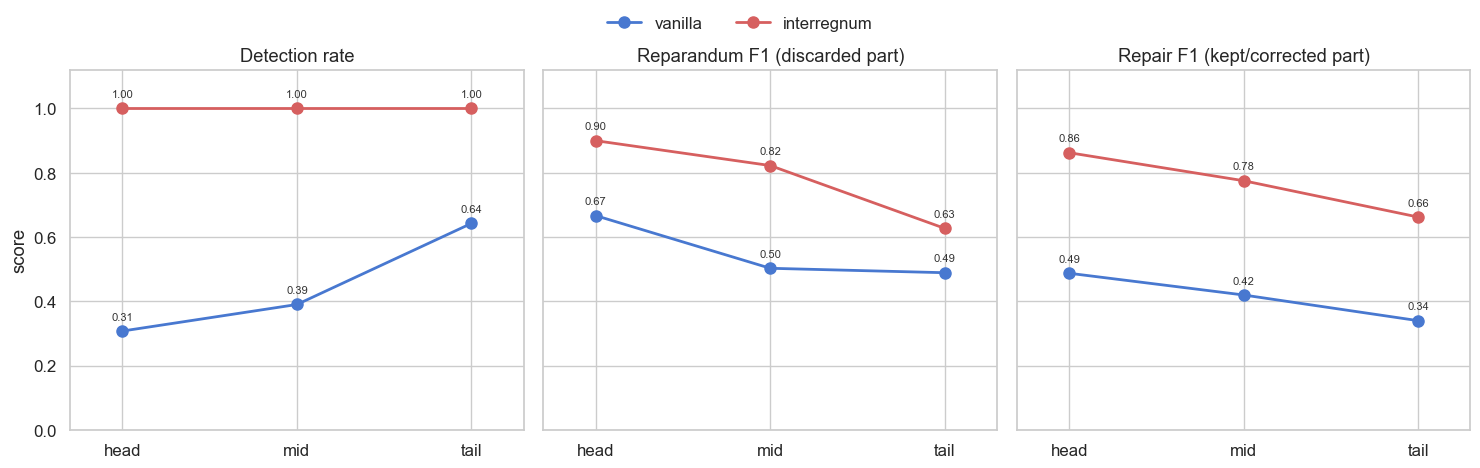

In [11]:
POSITION_X = {"head": 0, "mid": 1, "tail": 2}
GROUP_COLOR = {"vanilla": "#4878d0", "interregnum": "#d65f5f"}  # same hues as repair_head / repair_head_interrug in Q1

def pos_of(cond):
    for p in POSITION_ORDER:
        if f"_{p}" in cond:
            return p

metrics = [
    ("detection_rate", "Detection rate"),
    ("reparandum_f1", "Reparandum F1 (discarded part)"),
    ("repair_f1", "Repair F1 (kept/corrected part)"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, (col, title) in zip(axes, metrics):
    for group_label, summ, conds in [("vanilla", vanilla_summary, AB_VANILLA), ("interregnum", interreg_summary, AB_INTERREG)]:
        xs = [POSITION_X[pos_of(c)] for c in conds]
        ys = [summ.loc[c, col] for c in conds]
        ax.plot(xs, ys, "-o", color=GROUP_COLOR[group_label], lw=2, markersize=8, label=group_label)
        for x, y in zip(xs, ys):
            ax.annotate(f"{y:.2f}", (x, y), textcoords="offset points", xytext=(0, 8),
                        ha="center", fontsize=8, color="#333333")
    ax.set_title(title)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["head", "mid", "tail"])
    ax.set_xlim(-0.3, 2.3)
    ax.set_ylim(0, 1.12)

axes[0].set_ylabel("score")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.06), frameon=False)

plt.tight_layout()
plt.savefig(FIG_DIR / "q4_ablation_slopegraph.png", dpi=150, bbox_inches="tight")
plt.show()

**Reading the chart.** The `gold` false-positive rate is 0.96% (8/836) — the model is not simply saying "yes" to everything, so the pattern below reflects a real difference in sensitivity, not a guessing bias.

Interregnum detection sits at a flat 100% across all three positions — this is best read as the model correctly segmenting a sentence around a highly conventionalised marker phrase ("I mean"), not as evidence that it understands self-repair as a phenomenon. Vanilla is the condition that actually tests that, with no lexical scaffold to lean on: detection ranges from 30.7% (head) up to 64.2% (tail), well short of ceiling and strongly position-dependent — this position effect is confirmed by Cochran's Q on the full sample (see the paired tests below) and is not in doubt.

Localization quality (among sentences where detection succeeded) shows a head > mid > tail-ish pattern in both sets of means, but the paired test below only confirms this as a systematic position effect for **interregnum** (Friedman p ≈ 5e-57 for reparandum, p ≈ 2e-22 for repair, N=823). The equivalent test for **vanilla is not significant** (p=0.165 and p=0.853, N=88 — the N shrinks that far because it requires a sentence to be a clean detection in all three vanilla positions *at once*, and vanilla's own detection rate is only 31–64%). This is reported here as a descriptive pattern only, not a confirmed effect, and the gap isn't purely a power problem to regret: interregnum detection is anchored to one fixed, unambiguous literal, while the vanilla reparandum/repair boundary is a comparatively abstract lexical-syntactic encoding of relative position with no single surface anchor — a clean, monotonic position effect on top of that abstraction would arguably be surprising even with more data. One further descriptive note: `repair_f1` in `repair_tail_interrug` edges slightly above `reparandum_f1` there (0.662 vs 0.627), the only condition where that ordering flips.

This gives a more direct answer to the question Q3 left open: at least part of the "gluing" behaviour documented there likely originates in an incomplete linguistic-level detection of *unmarked* self-repair, not solely in an inability to act on a repair once it has been correctly noticed. Without a marker word, the base model misses a self-repair outright in somewhere between a third (tail) and two-thirds (head) of cases — before the SBN task even enters the picture. That claim rests on the detection-rate result, which is unambiguous; the finer-grained claim about *how* localization quality degrades within vanilla by position is left open pending more data.

One data point that doesn't fit either the "detect" or "localize" story: `malformed` (unparseable) output jumps sharply for `repair_tail_interrug` (19.3%, vs 0.6–4.9% in the other five repair conditions) even though detection there is still 100%. Quality erosion toward the end of the sentence shows up even in the condition where the marker word has already removed the detection difficulty entirely — so it is likely a more general property of how this model handles sentence-final material, not something specific to self-repair.

**Methodological note on the `repair` metric.** Ground truth for the "kept/corrected" span was initially defined as the entire `gold` sentence. Once the model's raw outputs came back, it was clear the model consistently returns only the minimal token span that replaces the reparandum (e.g. reparandum `"199 bn,"` → repair `"201 bn"`, not the full twelve-word sentence) — scoring that against a whole-sentence target made the metric uninterpretable regardless of whether the model's answer was linguistically right. Ground truth was revised to the gold tokens immediately following the insertion point, length-matched to the reparandum span (see `ground_truth.py` docstring for the full rationale); the numbers reported throughout this section use that revised definition.

In [12]:
# Reuses cochrans_q / mcnemar / holm_correct / friedmanchisquare defined in Q2 above —
# same paired repeated-measures logic, applied to this ablation's detected/f1 columns.

def run_group_ablation(conditions, label):
    sub = ab[ab["condition"].isin(conditions)].copy()
    pairs = list(itertools.combinations(conditions, 2))

    wide_det = sub.pivot(index="id", columns="condition", values="detected").astype(int).dropna()[conditions]
    print(f"=== {label}: detection rate (N={len(wide_det)}) ===")
    print(wide_det.mean().round(4).to_string())
    if wide_det.values.std() == 0:
        print("all conditions at 100% detection — zero variance, Cochran's Q / McNemar undefined (ceiling effect)\n")
    else:
        Q, dfree, pQ = cochrans_q(wide_det.values)
        raw_p = np.array([mcnemar(wide_det[a].values, wide_det[b].values)[1] for a, b in pairs])
        holm_p = holm_correct(raw_p)
        det_pairwise = pd.DataFrame({
            "pair": [f"{a} vs {b}" for a, b in pairs],
            "p_raw": raw_p, "p_holm": holm_p, "significant": holm_p < 0.05,
        })
        print(f"Cochran's Q = {Q:.2f}, df={dfree}, p = {pQ:.3g}\n")
        display(det_pairwise)

    tp = sub[sub["detected"] & sub["gt_positive"] & ~sub["suspect"]]
    for metric in ("reparandum_f1", "repair_f1"):
        wide_f1 = tp.pivot(index="id", columns="condition", values=metric)[conditions].dropna()
        stat_fr, p_fr = friedmanchisquare(*[wide_f1[c] for c in conditions])
        print(f"=== {label}: {metric} among clean true positives (N={len(wide_f1)}) ===")
        print(wide_f1.mean().round(4).to_string())
        print(f"Friedman chi2 = {stat_fr:.2f}, p = {p_fr:.3g}\n")

run_group_ablation(AB_VANILLA, "Vanilla")
run_group_ablation(AB_INTERREG, "Interregnum")

=== Vanilla: detection rate (N=836) ===
condition
repair_head    0.3074
repair_mid     0.3900
repair_tail    0.6423
Cochran's Q = 218.63, df=2, p = 3.34e-48



,pair,p_raw,p_holm,significant
0,repair_head vs repair_mid,2.512358e-04,2.512358e-04,True
1,repair_head vs repair_tail,1.891509e-41,5.674526e-41,True
2,repair_mid vs repair_tail,4.272533e-26,8.545067e-26,True


=== Vanilla: reparandum_f1 among clean true positives (N=88) ===
condition
repair_head    0.6360
repair_mid     0.5432
repair_tail    0.4659
Friedman chi2 = 3.60, p = 0.165

=== Vanilla: repair_f1 among clean true positives (N=88) ===
condition
repair_head    0.4136
repair_mid     0.4420
repair_tail    0.4095
Friedman chi2 = 0.32, p = 0.853

=== Interregnum: detection rate (N=836) ===
condition
repair_head_interrug    1.0
repair_mid_interrug     1.0
repair_tail_interrug    1.0
all conditions at 100% detection — zero variance, Cochran's Q / McNemar undefined (ceiling effect)



=== Interregnum: reparandum_f1 among clean true positives (N=823) ===
condition
repair_head_interrug    0.8993
repair_mid_interrug     0.8227
repair_tail_interrug    0.6263
Friedman chi2 = 259.17, p = 5.27e-57

=== Interregnum: repair_f1 among clean true positives (N=823) ===
condition
repair_head_interrug    0.8616
repair_mid_interrug     0.7752
repair_tail_interrug    0.6618
Friedman chi2 = 99.57, p = 2.39e-22



## Limitations

- **F1-among-successes is a complete-case analysis.** It excludes sentences that failed in any of the three conditions of a group, which is a much larger exclusion for interregnum (51% of sentences) than for vanilla (13%). The Q2 F1 finding likely understates the effect, since the hardest sentences are removed before the F1 comparison even starts.
- **Q3 is a small, purposively-sampled qualitative account**, not a statistical test. It explains a plausible mechanism and grounds it in real examples, but the counts backing the "well supported" claim above (interregnum parse_error) come from the full dataset; the rest of the mechanism account has not been verified at that scale.
- **Out of scope for this report:** whether the interregnum's disruption reflects it operating on a distinct meta-linguistic layer that should not be represented inside the meaning representation itself. That is a theoretical claim the author holds as a working hypothesis; it is not something this data, on its own, establishes.
- **Q4 tests sensitivity to one marker only.** "I mean" is the only interregnum literal in this dataset. The claim that interregnum performance reflects marker-segmentation rather than self-repair understanding rests on this one marker being unusually conventionalised — whether other self-repair markers (e.g. "or rather", "sorry", "actually") would show the same near-ceiling detection is untested.
- **Q4's vanilla sentences are constructed by insertion**, not drawn from spontaneous speech. A head-position insertion can sometimes still parse as a grammatically valid appositive/vocative reading (see the `"Jerry, Tom threw..."` example), which may inflate the difficulty of vanilla detection relative to naturally-occurring, unmarked self-repair.
- **Q4 uses a single zero-shot prompt** (the knowledge-injection variant with explicit reparandum/interregnum/repair definitions — see the ablation's design notes for why a bare-language variant was piloted and dropped). The reported detection/localization numbers are a lower bound under this specific elicitation, not a ceiling on what the base model could do under few-shot or chain-of-thought prompting.
- **Q4's vanilla localization-by-position effect is descriptive, not confirmed.** The paired Friedman test for reparandum_f1 and repair_f1 across vanilla's three positions is not significant (p=0.165, p=0.853, N=88 complete-case triplets) — unlike the same test for interregnum, which is significant at N=823. The small vanilla N is itself partly explained by vanilla's low detection rate (a triplet requires clean detection in all three positions at once), so this may be a power issue; but it may just as plausibly reflect that the vanilla reparandum/repair boundary — an abstract lexical-syntactic encoding of relative position with no fixed surface anchor — does not produce as clean a position effect as a fixed marker phrase does, even in principle.